# MEE344 Machine Learning Term Project

## Electricity Consumption Forecasting

This notebook predicts hourly electricity consumption using real-time consumption and production data.

**Target:** `Tuketim_t`, hourly electricity consumption at prediction time `t`.

**Main model features:** calendar variables, lagged consumption values, rolling consumption statistics, lagged production total, and lagged production-source values.

The main forecasting setup does **not** use same-time consumption or same-time production values as features.

# 1. Data Loading, Merging, and Preprocessing

The production and consumption CSV files are loaded, parsed into a common `datetime` column, merged by timestamp, and checked for missing values, duplicate timestamps, and hourly continuity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PRODUCTION_FILENAME = "Gercek_Zamanli_Uretim-01062025-01092025(in).csv"
CONSUMPTION_FILENAME = "Gercek_Zamanli_Tuketim-01062025-01092025(in).csv"

def find_data_file(filename):
    candidates = [
        DATA_DIR / filename,
        Path.cwd() / filename,
        PROJECT_ROOT / filename,
        Path("/mnt/data") / filename,  # fallback for notebook checks outside the repo
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Checked: {candidates}")

PRODUCTION_PATH = find_data_file(PRODUCTION_FILENAME)
CONSUMPTION_PATH = find_data_file(CONSUMPTION_FILENAME)

print("Production file:", PRODUCTION_PATH)
print("Consumption file:", CONSUMPTION_PATH)

Production file: C:\Users\casua\Desktop\machine-learning-term-project\data\raw\Gercek_Zamanli_Uretim-01062025-01092025(in).csv
Consumption file: C:\Users\casua\Desktop\machine-learning-term-project\data\raw\Gercek_Zamanli_Tuketim-01062025-01092025(in).csv


In [2]:
# Production file: UTF-8, semicolon-separated, decimal comma
production = pd.read_csv(
    PRODUCTION_PATH,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

production["datetime"] = pd.to_datetime(
    production["Tarih"].astype(str) + " " + production["Saat"].astype(str),
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

production = production.sort_values("datetime").reset_index(drop=True)
production.head()

,Tarih,Saat,Toplam,Doğal Gaz,Barajlı,Linyit,Akarsu,İthal Kömür,Rüzgar,Güneş,Fuel Oil,Jeotermal,Asfaltit Kömür,Taş Kömür,Biyokütle,Nafta,LNG,Uluslararası,Atık Isı,datetime
0,1.06.2025,00:00,33683.29,3973.20,5546.51,5344.77,3066.13,7449.12,5767.55,0.02,82.61,1282.08,79.48,461.44,939.94,0,0,-388.31,78.75,2025-06-01 00:00:00
1,1.06.2025,01:00,31922.96,3919.76,4440.05,5334.59,2962.07,7223.17,5450.66,0.02,81.95,1295.04,81.69,471.33,933.66,0,0,-349.02,77.99,2025-06-01 01:00:00
2,1.06.2025,02:00,30264.93,3392.73,4162.75,5323.11,2799.71,6676.81,5295.44,0.02,82.65,1302.76,81.69,470.14,941.09,0,0,-342.50,78.53,2025-06-01 02:00:00
3,1.06.2025,03:00,29634.59,2120.49,4727.01,5287.57,2891.98,6571.34,5422.08,0.05,81.70,1305.33,79.48,465.67,934.30,0,0,-325.61,73.20,2025-06-01 03:00:00
4,1.06.2025,04:00,29130.76,1711.66,4193.63,5256.06,2899.93,6965.39,5503.18,2.68,76.91,1309.43,81.69,462.30,943.73,0,0,-348.57,72.74,2025-06-01 04:00:00


In [3]:
# Consumption file: cp1254/Turkish encoding and Turkish number format such as 33.758,78
consumption_raw = pd.read_csv(
    CONSUMPTION_PATH,
    sep=";",
    encoding="cp1254",
    dtype=str
)

consumption_col = [col for col in consumption_raw.columns if col not in ["Tarih", "Saat"]][0]

consumption = consumption_raw.rename(columns={consumption_col: "Tuketim"}).copy()
consumption["Tuketim"] = (
    consumption["Tuketim"]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

consumption["datetime"] = pd.to_datetime(
    consumption["Tarih"].astype(str) + " " + consumption["Saat"].astype(str),
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

consumption = consumption.sort_values("datetime").reset_index(drop=True)
consumption.head()

,Tarih,Saat,Tuketim,datetime
0,1.06.2025,00:00,33758.78,2025-06-01 00:00:00
1,1.06.2025,01:00,31994.89,2025-06-01 01:00:00
2,1.06.2025,02:00,30335.27,2025-06-01 02:00:00
3,1.06.2025,03:00,29698.17,2025-06-01 03:00:00
4,1.06.2025,04:00,29203.16,2025-06-01 04:00:00


In [4]:
# Merge by timestamp
df = production.merge(
    consumption[["datetime", "Tuketim"]],
    on="datetime",
    how="inner"
)

print("Production rows:", len(production))
print("Consumption rows:", len(consumption))
print("Merged rows:", len(df))

df.head()

Production rows: 2232
Consumption rows: 2232
Merged rows: 2232


,Tarih,Saat,Toplam,Doğal Gaz,Barajlı,Linyit,Akarsu,İthal Kömür,Rüzgar,Güneş,...,Jeotermal,Asfaltit Kömür,Taş Kömür,Biyokütle,Nafta,LNG,Uluslararası,Atık Isı,datetime,Tuketim
0,1.06.2025,00:00,33683.29,3973.20,5546.51,5344.77,3066.13,7449.12,5767.55,0.02,...,1282.08,79.48,461.44,939.94,0,0,-388.31,78.75,2025-06-01 00:00:00,33758.78
1,1.06.2025,01:00,31922.96,3919.76,4440.05,5334.59,2962.07,7223.17,5450.66,0.02,...,1295.04,81.69,471.33,933.66,0,0,-349.02,77.99,2025-06-01 01:00:00,31994.89
2,1.06.2025,02:00,30264.93,3392.73,4162.75,5323.11,2799.71,6676.81,5295.44,0.02,...,1302.76,81.69,470.14,941.09,0,0,-342.50,78.53,2025-06-01 02:00:00,30335.27
3,1.06.2025,03:00,29634.59,2120.49,4727.01,5287.57,2891.98,6571.34,5422.08,0.05,...,1305.33,79.48,465.67,934.30,0,0,-325.61,73.20,2025-06-01 03:00:00,29698.17
4,1.06.2025,04:00,29130.76,1711.66,4193.63,5256.06,2899.93,6965.39,5503.18,2.68,...,1309.43,81.69,462.30,943.73,0,0,-348.57,72.74,2025-06-01 04:00:00,29203.16


In [5]:
# Data quality checks
print("Shape:", df.shape)
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

missing = df.isna().sum()
print("\nMissing values:")
print(missing[missing > 0])

time_diffs = df["datetime"].diff().dropna()
print("\nTime-step counts:")
print(time_diffs.value_counts())
print("Non-hourly gaps:", (time_diffs != pd.Timedelta(hours=1)).sum())

Shape: (2232, 21)
Start: 2025-06-01 00:00:00
End: 2025-09-01 23:00:00
Duplicate timestamps: 0

Missing values:
Series([], dtype: int64)

Time-step counts:
datetime
0 days 01:00:00    2231
Name: count, dtype: int64
Non-hourly gaps: 0


In [6]:
# Remove constant production columns
constant_cols = [
    col for col in df.select_dtypes(include="number").columns
    if df[col].nunique() == 1
]
print("Constant numeric columns:", constant_cols)

df = df.drop(columns=[col for col in ["Nafta", "LNG"] if col in df.columns])

Constant numeric columns: ['Nafta', 'LNG']


In [7]:
# Production and consumption are related, but not exactly equal.
prod_cons_diff = df["Toplam"] - df["Tuketim"]

print("Correlation between production Toplam and consumption:")
print(df[["Toplam", "Tuketim"]].corr())

print("\nToplam - Tuketim summary:")
print(prod_cons_diff.describe())

print("\nAre Toplam and Tuketim exactly equal?", np.allclose(df["Toplam"], df["Tuketim"]))

Correlation between production Toplam and consumption:
           Toplam   Tuketim
Toplam   1.000000  0.746631
Tuketim  0.746631  1.000000

Toplam - Tuketim summary:
count     2232.000000
mean     -4810.370157
std       5502.135850
min     -16898.090000
25%     -10449.207500
50%      -1366.880000
75%        -65.907500
max        -13.290000
dtype: float64

Are Toplam and Tuketim exactly equal? False


## Modeling implication

`Toplam` and `Tuketim` are not exactly equal, so this is not the same leakage case as predicting production `Toplam` from same-time production-source columns.

However, the main task is a forecasting-style setup: predicting consumption at time `t` before observing that hour. Therefore, same-time production values such as `Toplam_t`, `Rüzgar_t`, or `Güneş_t` are excluded from the main model. They are replaced with lagged values such as `Toplam_lag_1` and `Rüzgar_lag_1`.

# 2. Exploratory Data Analysis

This section analyzes consumption patterns and motivates time-based and lag-based feature engineering.

In [8]:
summary = df.select_dtypes(include="number").agg(["min", "max", "mean", "std"]).T
summary

,min,max,mean,std
Toplam,11175.31,56219.06,39387.652903,7871.805956
Doğal Gaz,583.34,17028.01,9539.469565,4644.162785
Barajlı,1076.33,16722.49,5292.658392,3181.982984
Linyit,1775.49,6019.76,4498.630009,682.712463
Akarsu,451.69,4015.34,1469.348159,637.987730
İthal Kömür,3572.15,10172.67,9331.651254,1476.476946
Rüzgar,323.46,10612.45,5360.477935,2388.272920
Güneş,0.00,3394.37,1254.703535,1320.093339
Fuel Oil,44.21,109.22,86.112885,11.103434
Jeotermal,799.20,1314.83,1043.062307,96.718299


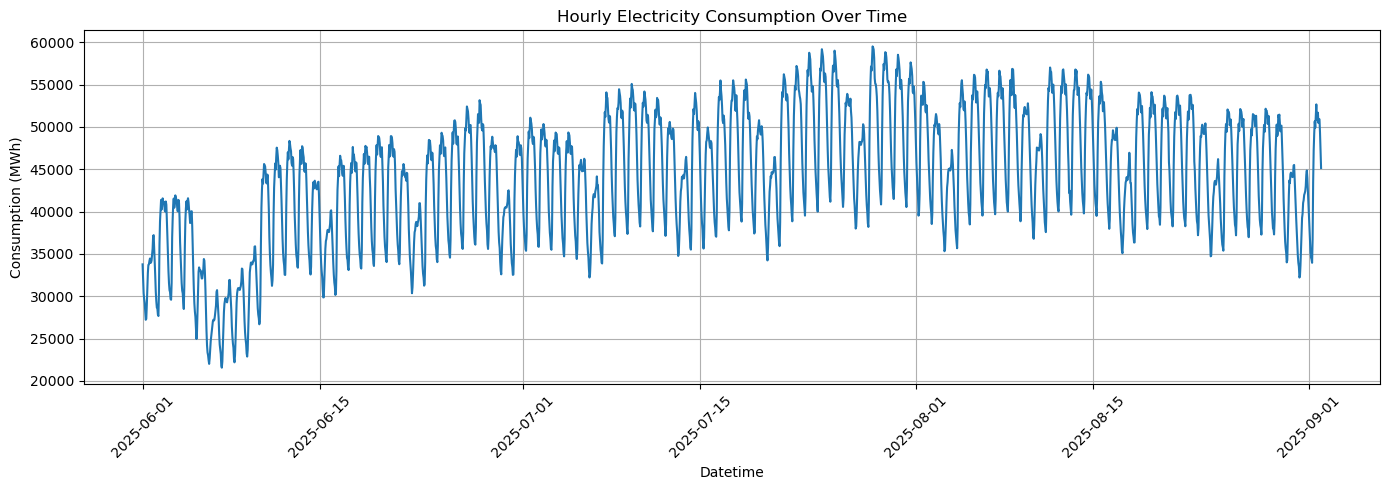

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["Tuketim"])
plt.xlabel("Datetime")
plt.ylabel("Consumption (MWh)")
plt.title("Hourly Electricity Consumption Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

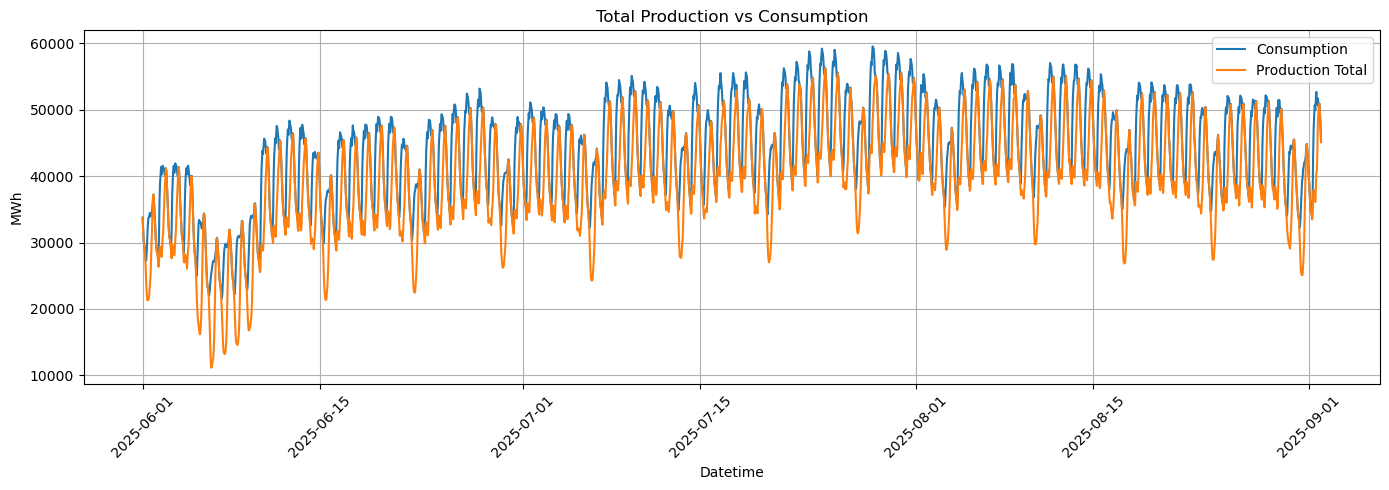

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["Tuketim"], label="Consumption")
plt.plot(df["datetime"], df["Toplam"], label="Production Total")
plt.xlabel("Datetime")
plt.ylabel("MWh")
plt.title("Total Production vs Consumption")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

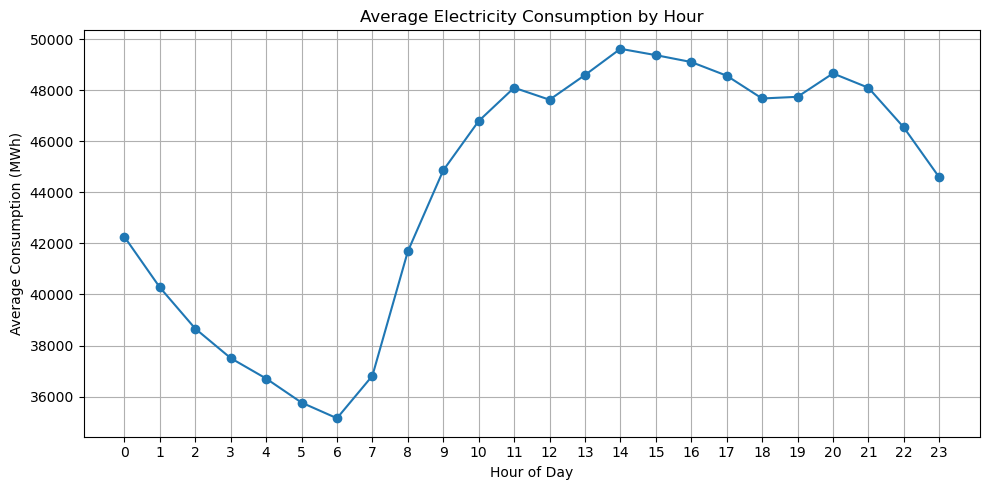

In [11]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["date"] = df["datetime"].dt.date

hourly_consumption = df.groupby("hour")["Tuketim"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_consumption.index, hourly_consumption.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.title("Average Electricity Consumption by Hour")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

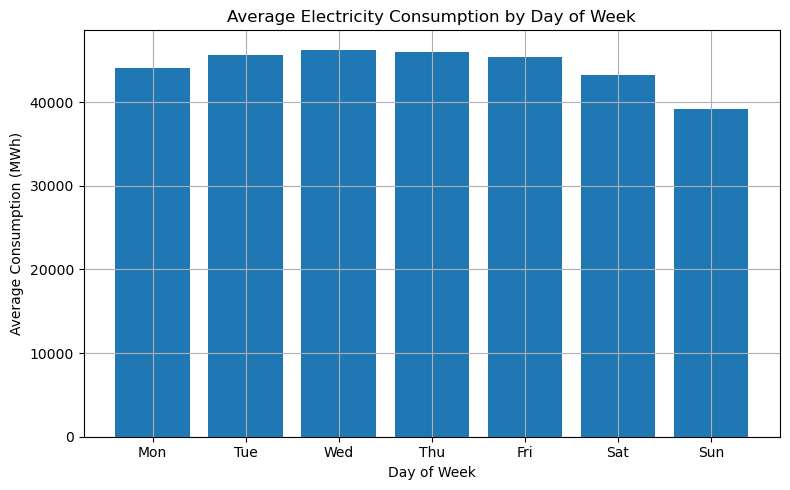

In [12]:
dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_consumption = df.groupby("dayofweek")["Tuketim"].mean()

plt.figure(figsize=(8, 5))
plt.bar([dow_map[i] for i in dow_consumption.index], dow_consumption.values)
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (MWh)")
plt.title("Average Electricity Consumption by Day of Week")
plt.tight_layout()
plt.show()

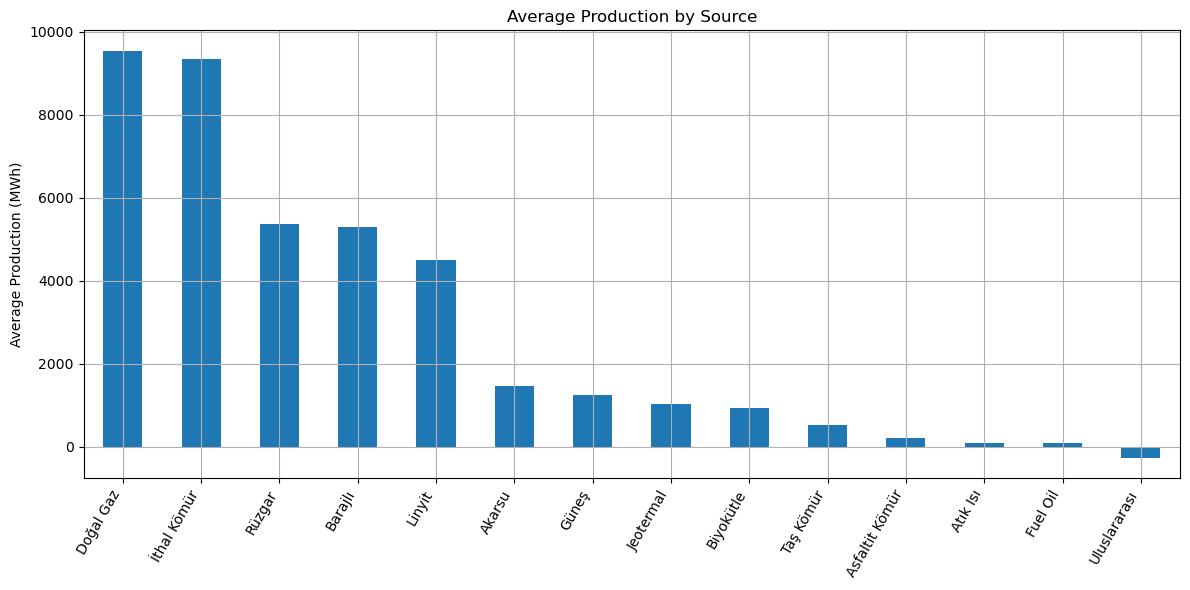

In [13]:
source_cols = [
    "Doğal Gaz", "Barajlı", "Linyit", "Akarsu", "İthal Kömür", "Rüzgar",
    "Güneş", "Fuel Oil", "Jeotermal", "Asfaltit Kömür", "Taş Kömür",
    "Biyokütle", "Uluslararası", "Atık Isı"
]

source_means = df[source_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
source_means.plot(kind="bar")
plt.ylabel("Average Production (MWh)")
plt.title("Average Production by Source")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [14]:
print("Consumption autocorrelation:")
for lag in [1, 2, 3, 24, 48, 168]:
    print(f"Lag {lag}: {df['Tuketim'].autocorr(lag=lag):.3f}")

Consumption autocorrelation:
Lag 1: 0.972
Lag 2: 0.905
Lag 3: 0.815
Lag 24: 0.887
Lag 48: 0.799
Lag 168: 0.879


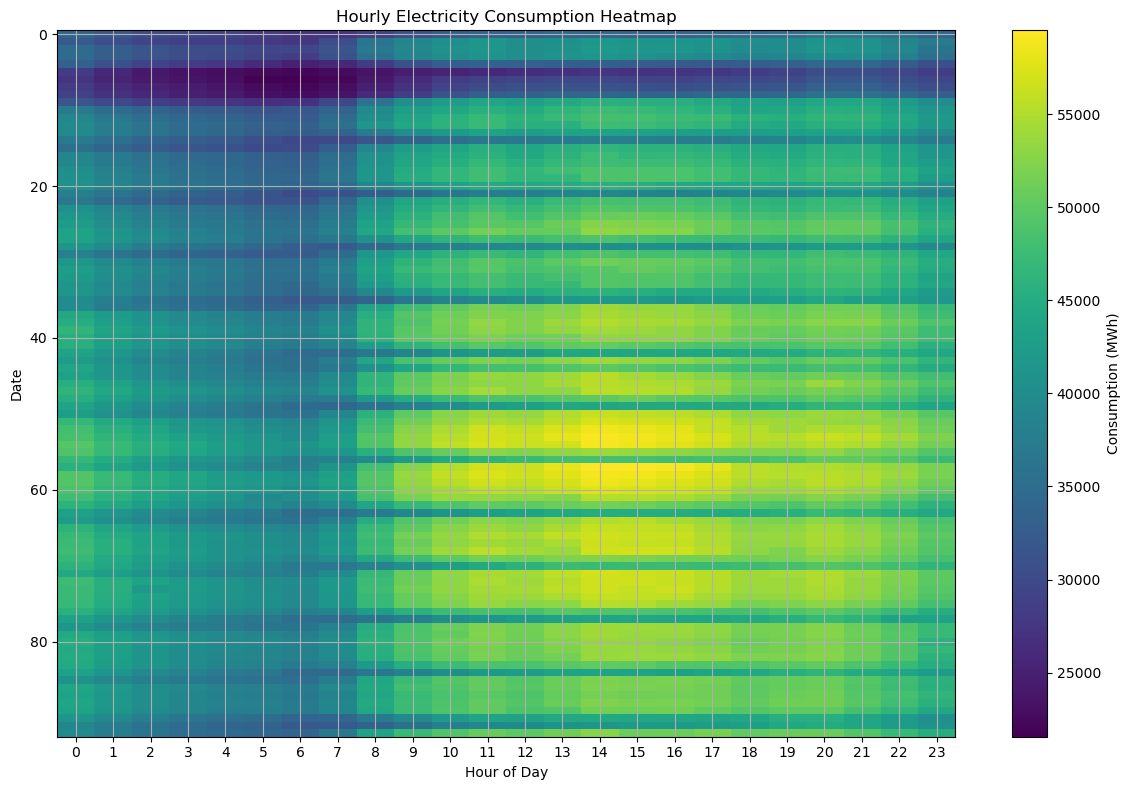

In [15]:
pivot = df.pivot_table(
    index=df["datetime"].dt.date,
    columns=df["datetime"].dt.hour,
    values="Tuketim",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Consumption (MWh)")
plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.title("Hourly Electricity Consumption Heatmap")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# 3. Feature Engineering

The target is `Tuketim_t`. The feature matrix uses calendar variables, lagged consumption values, rolling statistics from past consumption, and lagged production values.

Same-time `Tuketim_t`, `Toplam_t`, and same-time production-source values are not included in the main feature matrix.

In [16]:
df_fe = df.copy()
df_fe["target"] = df_fe["Tuketim"]

# Calendar features
df_fe["hour"] = df_fe["datetime"].dt.hour
df_fe["dayofweek"] = df_fe["datetime"].dt.dayofweek
df_fe["day"] = df_fe["datetime"].dt.day
df_fe["month"] = df_fe["datetime"].dt.month
df_fe["is_weekend"] = df_fe["dayofweek"].isin([5, 6]).astype(int)

df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["hour"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["hour"] / 24)
df_fe["dow_sin"] = np.sin(2 * np.pi * df_fe["dayofweek"] / 7)
df_fe["dow_cos"] = np.cos(2 * np.pi * df_fe["dayofweek"] / 7)

calendar_features = [
    "hour", "dayofweek", "day", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos"
]

# Consumption lag features
consumption_lags = [1, 2, 3, 24, 48, 168]
for lag in consumption_lags:
    df_fe[f"Tuketim_lag_{lag}"] = df_fe["Tuketim"].shift(lag)
consumption_lag_features = [f"Tuketim_lag_{lag}" for lag in consumption_lags]

# Production total lag features
production_total_lags = [1, 2, 3, 24, 48, 168]
for lag in production_total_lags:
    df_fe[f"Toplam_lag_{lag}"] = df_fe["Toplam"].shift(lag)
production_total_lag_features = [f"Toplam_lag_{lag}" for lag in production_total_lags]

# Production source lag features
source_lag_features = []
for col in source_cols:
    feature_name = f"{col}_lag_1"
    df_fe[feature_name] = df_fe[col].shift(1)
    source_lag_features.append(feature_name)

# Consumption rolling features; shift before rolling to avoid using the target row.
rolling_windows = [3, 6, 24]
consumption_rolling_features = []
for window in rolling_windows:
    mean_name = f"Tuketim_roll_{window}_mean"
    std_name = f"Tuketim_roll_{window}_std"
    df_fe[mean_name] = df_fe["Tuketim"].shift(1).rolling(window).mean()
    df_fe[std_name] = df_fe["Tuketim"].shift(1).rolling(window).std()
    consumption_rolling_features.extend([mean_name, std_name])

# Trend features
# These are based only on lagged values.
df_fe["Tuketim_diff_1"] = df_fe["Tuketim_lag_1"] - df_fe["Tuketim_lag_2"]
df_fe["Tuketim_diff_24"] = df_fe["Tuketim_lag_1"] - df_fe["Tuketim_lag_24"]
trend_features = ["Tuketim_diff_1", "Tuketim_diff_24"]

# Feature sets
baseline_features = calendar_features
consumption_history_features = calendar_features + consumption_lag_features + consumption_rolling_features + trend_features
main_features = (
    calendar_features
    + consumption_lag_features
    + consumption_rolling_features
    + trend_features
    + production_total_lag_features
    + source_lag_features
)

required_cols = ["target"] + main_features
df_model = df_fe.dropna(subset=required_cols).copy()

X_calendar = df_model[baseline_features].copy()
X_consumption_history = df_model[consumption_history_features].copy()
X_main = df_model[main_features].copy()
y = df_model["target"].copy()

print("Original rows:", len(df_fe))
print("Rows after feature engineering:", len(df_model))
print("Rows removed:", len(df_fe) - len(df_model))
print("Calendar-only feature count:", X_calendar.shape[1])
print("Consumption-history feature count:", X_consumption_history.shape[1])
print("Main feature count:", X_main.shape[1])
print("Samples:", X_main.shape[0])

Original rows: 2232
Rows after feature engineering: 2064
Rows removed: 168
Calendar-only feature count: 9
Consumption-history feature count: 23
Main feature count: 43
Samples: 2064


In [17]:
# Leakage check
forbidden_cols = ["Tuketim", "Toplam"] + source_cols
leaked_cols = [col for col in forbidden_cols if col in X_main.columns]

print("Leakage columns found:", leaked_cols)

assert "target" not in X_main.columns
assert "Tuketim" not in X_main.columns
assert "Toplam" not in X_main.columns
assert len(leaked_cols) == 0
assert X_main.isna().sum().sum() == 0
assert y.isna().sum() == 0

preview_cols = ["datetime", "target"] + main_features[:12]
df_model[preview_cols].head()

Leakage columns found: []


,datetime,target,hour,dayofweek,day,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,Tuketim_lag_1,Tuketim_lag_2,Tuketim_lag_3
168,2025-06-08 00:00:00,28331.73,0,6,8,6,1,0.000000,1.000000,-0.781831,0.62349,29579.15,30727.76,31922.80
169,2025-06-08 01:00:00,26431.23,1,6,8,6,1,0.258819,0.965926,-0.781831,0.62349,28331.73,29579.15,30727.76
170,2025-06-08 02:00:00,25246.75,2,6,8,6,1,0.500000,0.866025,-0.781831,0.62349,26431.23,28331.73,29579.15
171,2025-06-08 03:00:00,24433.18,3,6,8,6,1,0.707107,0.707107,-0.781831,0.62349,25246.75,26431.23,28331.73
172,2025-06-08 04:00:00,23913.47,4,6,8,6,1,0.866025,0.500000,-0.781831,0.62349,24433.18,25246.75,26431.23


In [18]:
feature_corr = X_main.copy()
feature_corr["target"] = y

corr_with_target = (
    feature_corr.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

corr_with_target.head(15)

Tuketim_lag_1           0.965456
Tuketim_roll_3_mean     0.891417
Tuketim_lag_2           0.881833
Tuketim_lag_168         0.879440
Tuketim_lag_24          0.871927
Tuketim_lag_48          0.789135
Tuketim_lag_3           0.771080
Tuketim_roll_6_mean     0.750522
Jeotermal_lag_1        -0.727712
hour_sin               -0.608705
Tuketim_roll_24_mean    0.608340
Toplam_lag_168          0.592259
Toplam_lag_1            0.588164
Toplam_lag_24           0.562442
hour                    0.543146
Name: target, dtype: float64

# 4. Chronological Split and TimeSeriesSplit

The final 15% of the timeline is reserved as the untouched test set. `TimeSeriesSplit` is used inside the earlier 85% for hyperparameter tuning.

In [19]:
X = X_main.copy()
y = y.copy()

test_ratio = 0.15
test_size = int(len(X) * test_ratio)

X_trainval = X.iloc[:-test_size].copy()
y_trainval = y.iloc[:-test_size].copy()
X_test = X.iloc[-test_size:].copy()
y_test = y.iloc[-test_size:].copy()

trainval_start = df_model["datetime"].iloc[0]
trainval_end = df_model["datetime"].iloc[len(X_trainval) - 1]
test_start = df_model["datetime"].iloc[len(X_trainval)]
test_end = df_model["datetime"].iloc[-1]

print("Total samples:", len(X))
print("Train-validation samples:", len(X_trainval))
print("Test samples:", len(X_test))
print("\nTrain-validation period:", trainval_start, "→", trainval_end)
print("Test period:", test_start, "→", test_end)

tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 7)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval), start=1):
    print(f"Fold {fold}: train={len(train_idx)} samples, validation={len(val_idx)} samples")

Total samples: 2064
Train-validation samples: 1755
Test samples: 309

Train-validation period: 2025-06-08 00:00:00 → 2025-08-20 02:00:00
Test period: 2025-08-20 03:00:00 → 2025-09-01 23:00:00
Fold 1: train=915 samples, validation=168 samples
Fold 2: train=1083 samples, validation=168 samples
Fold 3: train=1251 samples, validation=168 samples
Fold 4: train=1419 samples, validation=168 samples
Fold 5: train=1587 samples, validation=168 samples


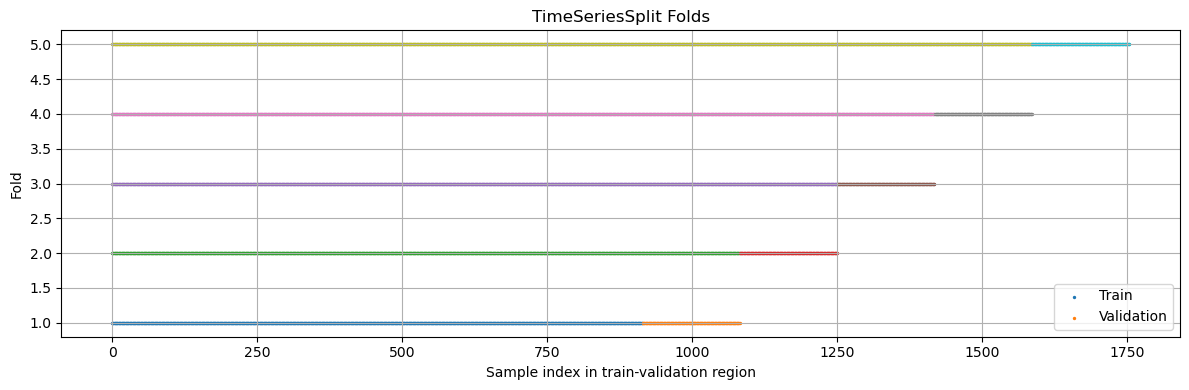

In [20]:
plt.figure(figsize=(12, 4))
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval), start=1):
    plt.scatter(train_idx, [fold] * len(train_idx), s=2, label="Train" if fold == 1 else None)
    plt.scatter(val_idx, [fold] * len(val_idx), s=2, label="Validation" if fold == 1 else None)
plt.xlabel("Sample index in train-validation region")
plt.ylabel("Fold")
plt.title("TimeSeriesSplit Folds")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
def evaluate_regression(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    mse = mean_squared_error(y_eval, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_eval, y_pred)
    r2 = r2_score(y_eval, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

split_summary = {
    "total_samples": len(X),
    "trainval_samples": len(X_trainval),
    "test_samples": len(X_test),
    "trainval_start": trainval_start,
    "trainval_end": trainval_end,
    "test_start": test_start,
    "test_end": test_end,
    "n_splits": 5,
    "cv_validation_size_hours": 24 * 7,
}

split_summary

{'total_samples': 2064,
 'trainval_samples': 1755,
 'test_samples': 309,
 'trainval_start': Timestamp('2025-06-08 00:00:00'),
 'trainval_end': Timestamp('2025-08-20 02:00:00'),
 'test_start': Timestamp('2025-08-20 03:00:00'),
 'test_end': Timestamp('2025-09-01 23:00:00'),
 'n_splits': 5,
 'cv_validation_size_hours': 168}

# 5. Decision Tree Model

A baseline Decision Tree is trained first. Then a tuned Decision Tree is selected using `GridSearchCV` with `TimeSeriesSplit`. The tuned model is evaluated on the untouched final test period.

In [22]:
# Baseline Decision Tree
baseline_tree = DecisionTreeRegressor(random_state=42)
baseline_tree.fit(X_trainval, y_trainval)

baseline_tree_train_results = evaluate_regression(baseline_tree, X_trainval, y_trainval)
baseline_tree_test_results = evaluate_regression(baseline_tree, X_test, y_test)

print("Baseline Decision Tree - Train:")
print(baseline_tree_train_results)
print("\nBaseline Decision Tree - Test:")
print(baseline_tree_test_results)

Baseline Decision Tree - Train:
{'RMSE': np.float64(0.0), 'MAE': 0.0, 'R2': 1.0}

Baseline Decision Tree - Test:
{'RMSE': np.float64(1011.9195471114359), 'MAE': 739.6881229773463, 'R2': 0.9688206735050302}


In [23]:
# Hyperparameter tuning
tree_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None],
}

tree_grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=tree_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=1,
    return_train_score=True,
)

tree_grid_search.fit(X_trainval, y_trainval)

print("Best Decision Tree parameters:")
print(tree_grid_search.best_params_)
print("\nBest CV RMSE:", -tree_grid_search.best_score_)

Best Decision Tree parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best CV RMSE: 1588.9853085326572


In [24]:
best_tree = tree_grid_search.best_estimator_

tuned_tree_train_results = evaluate_regression(best_tree, X_trainval, y_trainval)
tuned_tree_test_results = evaluate_regression(best_tree, X_test, y_test)

print("Tuned Decision Tree - Train:")
print(tuned_tree_train_results)
print("\nTuned Decision Tree - Test:")
print(tuned_tree_test_results)

print("\n=============================================")
print("        DECISION TREE MODEL RESULTS          ")
print("=============================================")
print(f"RMSE: {tuned_tree_test_results['RMSE']:.4f}")
print(f"MAE:  {tuned_tree_test_results['MAE']:.4f}")
print(f"R²:   {tuned_tree_test_results['R2']:.4f}")
print("=============================================\n")

tree_comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_tree_test_results,
    "Tuned Decision Tree": tuned_tree_test_results,
}).T

decision_tree_results_table = tree_comparison.round(3)
decision_tree_results_table

Tuned Decision Tree - Train:
{'RMSE': np.float64(442.6729682210242), 'MAE': 318.8886269934869, 'R2': 0.996075243490983}

Tuned Decision Tree - Test:
{'RMSE': np.float64(1004.1003435769754), 'MAE': 759.1489289027478, 'R2': 0.9693006633951232}

        DECISION TREE MODEL RESULTS          
RMSE: 1004.1003
MAE:  759.1489
R²:   0.9693



,RMSE,MAE,R2
Baseline Decision Tree,1011.92,739.688,0.969
Tuned Decision Tree,1004.10,759.149,0.969


In [25]:
# Cross-validation results
tree_cv_results = pd.DataFrame(tree_grid_search.cv_results_)
tree_cv_results["mean_train_RMSE"] = -tree_cv_results["mean_train_score"]
tree_cv_results["mean_val_RMSE"] = -tree_cv_results["mean_test_score"]

tree_cv_results_sorted = tree_cv_results.sort_values(by="mean_val_RMSE")
tree_cv_results_sorted[
    [
        "mean_train_RMSE",
        "mean_val_RMSE",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
    ]
].head(10)

,mean_train_RMSE,mean_val_RMSE,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
39,477.692006,1588.985309,10,2,5,None
40,477.692006,1588.985309,10,10,5,None
52,468.271510,1589.326944,None,10,5,None
51,468.271510,1589.326944,None,2,5,None
53,653.987258,1593.729385,None,20,5,None
41,655.442221,1594.946400,10,20,5,None
43,713.186453,1602.026212,10,10,10,None
56,713.186453,1602.026212,None,20,10,None
55,713.186453,1602.026212,None,10,10,None
54,713.186453,1602.026212,None,2,10,None


## Decision Tree diagnostics

The following plots save presentation-ready figures into `figures/results/`. The train-vs-validation RMSE by tree depth helps show the overfitting behavior of deeper trees.

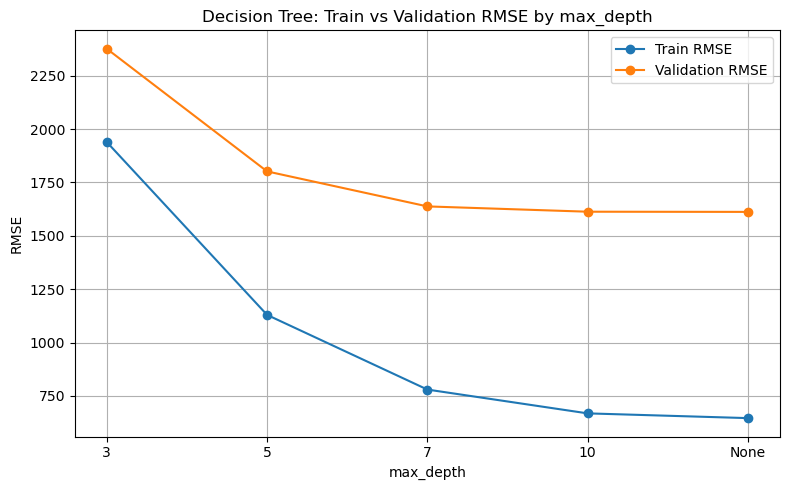

,max_depth_label,mean_train_RMSE,mean_val_RMSE
1,3,1938.652113,2375.634026
2,5,1129.492495,1801.481973
3,7,779.923762,1637.596425
0,10,668.418851,1612.797703
4,None,646.234520,1611.914578


In [26]:
# Train vs validation RMSE by tree depth
# This diagnostic helps explain why the selected tree depth is preferable.
depth_summary = (
    tree_cv_results
    .assign(max_depth_label=tree_cv_results["param_max_depth"].astype(str))
    .groupby("max_depth_label")[["mean_train_RMSE", "mean_val_RMSE"]]
    .mean()
    .reset_index()
)

# Keep a readable order on the x-axis
order = ["3", "5", "7", "10", "None"]
depth_summary["order"] = depth_summary["max_depth_label"].apply(lambda x: order.index(x) if x in order else 999)
depth_summary = depth_summary.sort_values("order")

plt.figure(figsize=(8, 5))
plt.plot(depth_summary["max_depth_label"], depth_summary["mean_train_RMSE"], marker="o", label="Train RMSE")
plt.plot(depth_summary["max_depth_label"], depth_summary["mean_val_RMSE"], marker="o", label="Validation RMSE")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Decision Tree: Train vs Validation RMSE by max_depth")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "decision_tree_depth_rmse.png", dpi=300)
plt.show()

depth_summary.drop(columns="order")

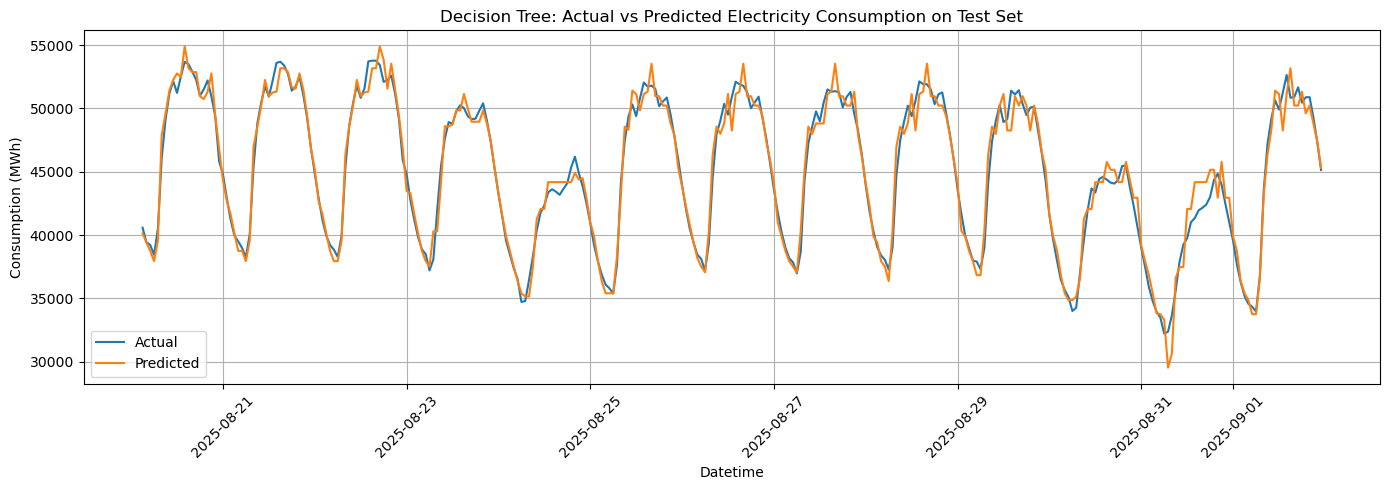

In [27]:
# Actual vs predicted plot
tree_test_pred = best_tree.predict(X_test)
test_datetimes = df_model["datetime"].iloc[-len(y_test):]

plt.figure(figsize=(14, 5))
plt.plot(test_datetimes, y_test.values, label="Actual")
plt.plot(test_datetimes, tree_test_pred, label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MWh)")
plt.title("Decision Tree: Actual vs Predicted Electricity Consumption on Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "decision_tree_actual_vs_predicted.png", dpi=300)
plt.show()

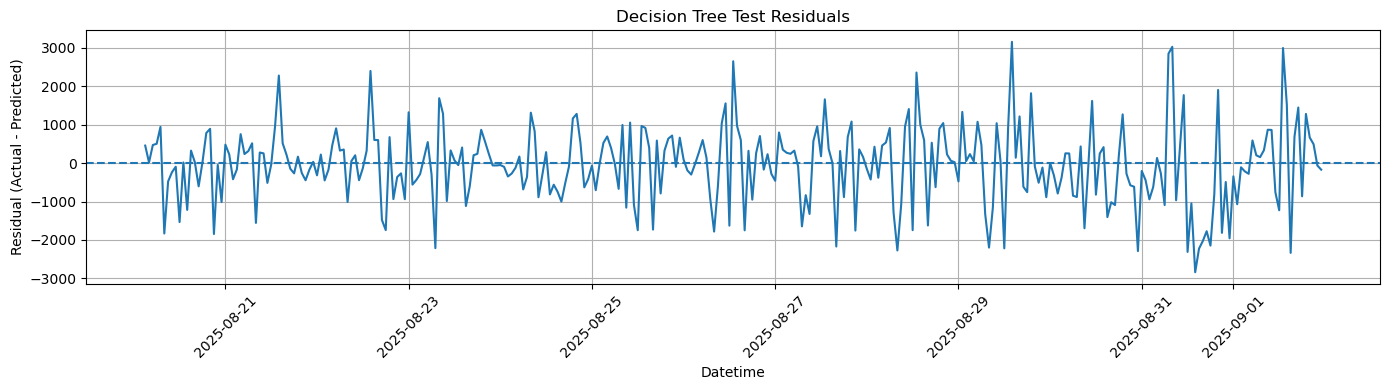

In [28]:
# Residual plot
tree_residuals = y_test.values - tree_test_pred

plt.figure(figsize=(14, 4))
plt.plot(test_datetimes, tree_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Decision Tree Test Residuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "decision_tree_residuals.png", dpi=300)
plt.show()

,feature,importance
9,Tuketim_lag_1,0.911776
0,hour,0.022827
21,Tuketim_diff_1,0.009837
35,Güneş_lag_1,0.009457
23,Toplam_lag_1,0.009012
14,Tuketim_lag_168,0.008880
12,Tuketim_lag_24,0.006086
16,Tuketim_roll_3_std,0.004230
1,dayofweek,0.003438
19,Tuketim_roll_24_mean,0.002678


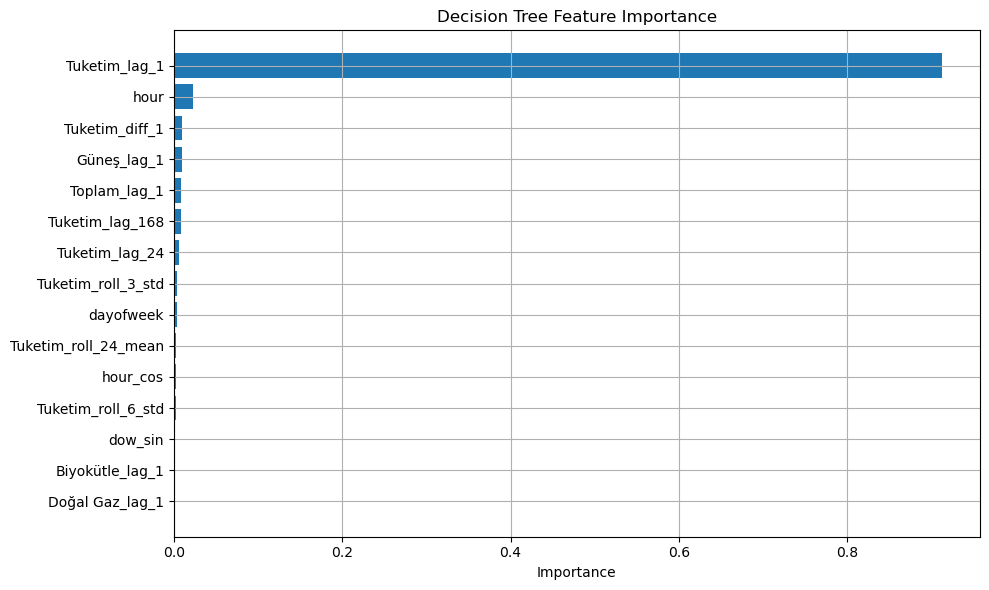

In [29]:
# Feature importance
tree_feature_importance = pd.DataFrame({
    "feature": X_trainval.columns,
    "importance": best_tree.feature_importances_,
}).sort_values(by="importance", ascending=False)

display(tree_feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    tree_feature_importance["feature"].head(15)[::-1],
    tree_feature_importance["importance"].head(15)[::-1],
)
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "decision_tree_feature_importance.png", dpi=300)
plt.show()

In [30]:
# Store model results for final comparison later
model_results = {}
model_results["Decision Tree Baseline"] = baseline_tree_test_results
model_results["Decision Tree Tuned"] = tuned_tree_test_results

model_results_df = pd.DataFrame(model_results).T.round(3)
model_results_df

,RMSE,MAE,R2
Decision Tree Baseline,1011.92,739.688,0.969
Decision Tree Tuned,1004.10,759.149,0.969


# 6. XGBoost Model

XGBoost is used as the second model. It is a gradient-boosted tree ensemble: instead of using one tree, it builds many trees sequentially, where each new tree attempts to correct the errors of the previous ensemble.

The same forecasting setup is used as in the Decision Tree section:

- same feature matrix,
- same chronological train/test split,
- same `TimeSeriesSplit` validation strategy,
- same final test period,
- same evaluation metrics.

In [31]:
from sklearn.model_selection import RandomizedSearchCV

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError("XGBoost is not installed. Install it with: pip install xgboost") from exc

In [32]:
# Baseline XGBoost model
# tree_method="hist" is efficient for tabular data.
xgb_baseline = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)

xgb_baseline.fit(X_trainval, y_trainval)

xgb_baseline_train_results = evaluate_regression(xgb_baseline, X_trainval, y_trainval)
xgb_baseline_test_results = evaluate_regression(xgb_baseline, X_test, y_test)

print("Baseline XGBoost - Train:")
print(xgb_baseline_train_results)
print("\nBaseline XGBoost - Test:")
print(xgb_baseline_test_results)

Baseline XGBoost - Train:
{'RMSE': np.float64(611.823007680564), 'MAE': 461.499078125, 'R2': 0.9925028133631958}

Baseline XGBoost - Test:
{'RMSE': np.float64(852.2225237831483), 'MAE': 647.4956108414239, 'R2': 0.9778853140813272}


In [33]:
# XGBoost hyperparameter tuning with TimeSeriesSplit
# A small manual search is used for speed and transparency.
# Each candidate is evaluated on the same time-series folds.

xgb_candidate_params = [
    {"n_estimators": 50, "max_depth": 2, "learning_rate": 0.10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 5.0},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.03, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 5.0},
]

xgb_cv_rows = []

for candidate_id, params in enumerate(xgb_candidate_params, start=1):
    fold_train_rmse = []
    fold_val_rmse = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval), start=1):
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        model = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            n_jobs=1,
            tree_method="hist",
            **params,
        )
        
        model.fit(X_fold_train, y_fold_train)
        
        train_pred = model.predict(X_fold_train)
        val_pred = model.predict(X_fold_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_fold_train, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred))
        
        fold_train_rmse.append(train_rmse)
        fold_val_rmse.append(val_rmse)
    
    row = {
        "candidate_id": candidate_id,
        "mean_train_RMSE": np.mean(fold_train_rmse),
        "mean_val_RMSE": np.mean(fold_val_rmse),
        **params,
    }
    xgb_cv_rows.append(row)

xgb_cv_results = pd.DataFrame(xgb_cv_rows).sort_values(by="mean_val_RMSE")
best_xgb_params = xgb_cv_results.iloc[0][list(xgb_candidate_params[0].keys())].to_dict()

# Convert integer-like params back to int for XGBRegressor
best_xgb_params["n_estimators"] = int(best_xgb_params["n_estimators"])
best_xgb_params["max_depth"] = int(best_xgb_params["max_depth"])

print("Best XGBoost parameters:")
print(best_xgb_params)
print("\nBest CV RMSE:", xgb_cv_results.iloc[0]["mean_val_RMSE"])

# Fit the selected XGBoost model on the full train-validation period
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=1,
    tree_method="hist",
    **best_xgb_params,
)

best_xgb.fit(X_trainval, y_trainval)

xgb_cv_results.head(10)

Best XGBoost parameters:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 5.0}

Best CV RMSE: 1055.7043028176772


,candidate_id,mean_train_RMSE,mean_val_RMSE,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_lambda
5,6,379.656742,1055.704303,200,4,0.03,0.9,0.9,5.0
3,4,439.083519,1078.215781,100,3,0.10,0.8,0.8,5.0
4,5,508.712008,1108.150115,200,3,0.03,0.9,0.9,1.0
2,3,572.818608,1162.922467,100,3,0.05,0.8,0.8,1.0
0,1,831.492301,1354.688014,50,2,0.10,0.8,0.8,1.0
1,2,834.614986,1359.824543,100,2,0.05,0.8,0.8,1.0


In [34]:
# Evaluate tuned XGBoost on train-validation and final test periods
xgb_tuned_train_results = evaluate_regression(best_xgb, X_trainval, y_trainval)
xgb_tuned_test_results = evaluate_regression(best_xgb, X_test, y_test)

print("Tuned XGBoost - Train:")
print(xgb_tuned_train_results)
print("\nTuned XGBoost - Test:")
print(xgb_tuned_test_results)

print("\n=============================================")
print("             XGBOOST MODEL RESULTS           ")
print("=============================================")
print(f"RMSE: {xgb_tuned_test_results['RMSE']:.4f}")
print(f"MAE:  {xgb_tuned_test_results['MAE']:.4f}")
print(f"R²:   {xgb_tuned_test_results['R2']:.4f}")
print("=============================================\n")

xgb_comparison = pd.DataFrame({
    "Baseline XGBoost": xgb_baseline_test_results,
    "Tuned XGBoost": xgb_tuned_test_results,
}).T

xgb_results_table = xgb_comparison.round(3)
xgb_results_table

Tuned XGBoost - Train:
{'RMSE': np.float64(414.92594812607666), 'MAE': 315.3175356125356, 'R2': 0.9965518360806183}

Tuned XGBoost - Test:
{'RMSE': np.float64(784.4116651511572), 'MAE': 591.9108156351132, 'R2': 0.9812646053183276}

             XGBOOST MODEL RESULTS           
RMSE: 784.4117
MAE:  591.9108
R²:   0.9813



,RMSE,MAE,R2
Baseline XGBoost,852.223,647.496,0.978
Tuned XGBoost,784.412,591.911,0.981


In [35]:
# XGBoost cross-validation results
xgb_cv_results_sorted = xgb_cv_results.sort_values(by="mean_val_RMSE")
xgb_cv_results_sorted.head(10)


,candidate_id,mean_train_RMSE,mean_val_RMSE,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_lambda
5,6,379.656742,1055.704303,200,4,0.03,0.9,0.9,5.0
3,4,439.083519,1078.215781,100,3,0.10,0.8,0.8,5.0
4,5,508.712008,1108.150115,200,3,0.03,0.9,0.9,1.0
2,3,572.818608,1162.922467,100,3,0.05,0.8,0.8,1.0
0,1,831.492301,1354.688014,50,2,0.10,0.8,0.8,1.0
1,2,834.614986,1359.824543,100,2,0.05,0.8,0.8,1.0


## XGBoost diagnostics

The following plots are saved into `figures/results/` for later use in the presentation.

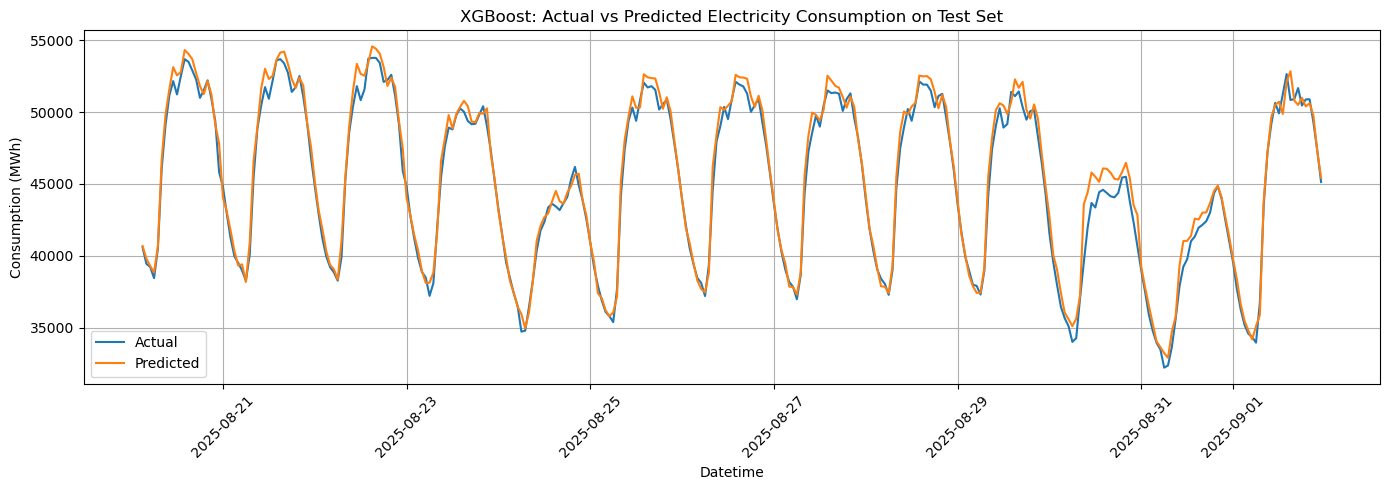

In [36]:
# Actual vs predicted plot for XGBoost
xgb_test_pred = best_xgb.predict(X_test)

test_datetimes = df_model["datetime"].iloc[-len(y_test):]

plt.figure(figsize=(14, 5))
plt.plot(test_datetimes, y_test.values, label="Actual")
plt.plot(test_datetimes, xgb_test_pred, label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MWh)")
plt.title("XGBoost: Actual vs Predicted Electricity Consumption on Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_actual_vs_predicted.png", dpi=300)
plt.show()

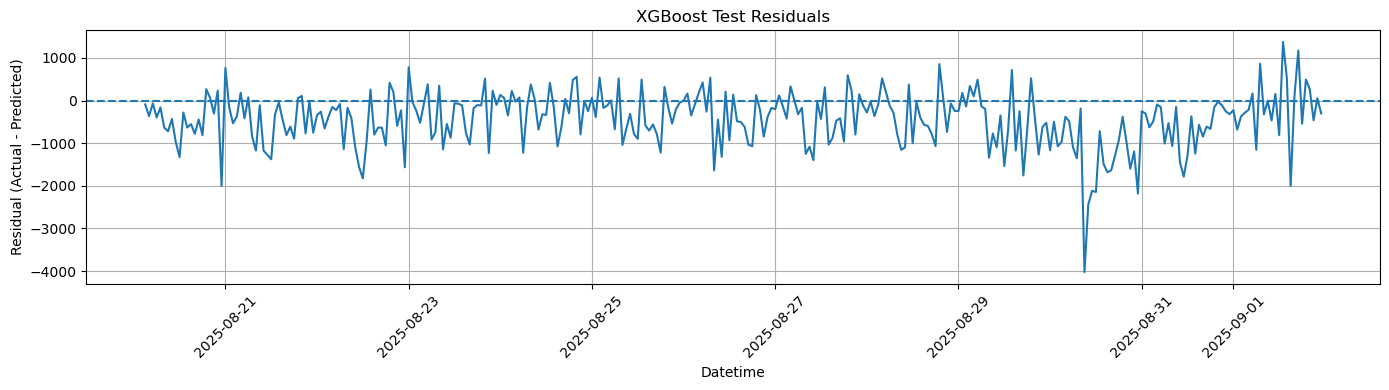

In [37]:
# XGBoost residual plot
xgb_residuals = y_test.values - xgb_test_pred

plt.figure(figsize=(14, 4))
plt.plot(test_datetimes, xgb_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost Test Residuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_residuals.png", dpi=300)
plt.show()

,feature,importance
14,Tuketim_lag_168,0.485946
9,Tuketim_lag_1,0.281198
15,Tuketim_roll_3_mean,0.052551
12,Tuketim_lag_24,0.024885
0,hour,0.018057
35,Güneş_lag_1,0.014943
3,month,0.014183
21,Tuketim_diff_1,0.011926
22,Tuketim_diff_24,0.011363
4,is_weekend,0.009555


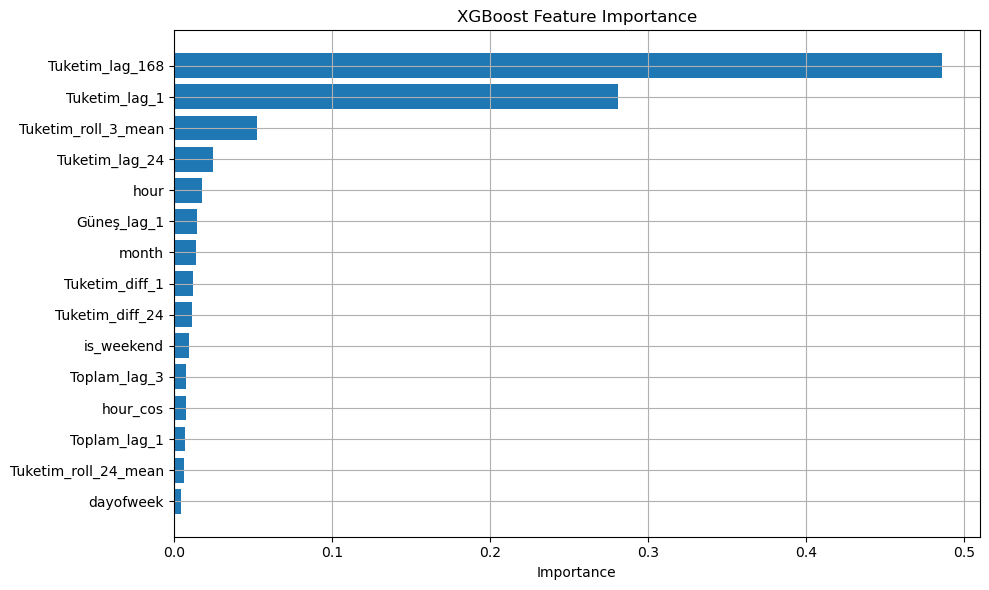

In [38]:
# XGBoost feature importance
xgb_feature_importance = pd.DataFrame({
    "feature": X_trainval.columns,
    "importance": best_xgb.feature_importances_,
}).sort_values(by="importance", ascending=False)

display(xgb_feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    xgb_feature_importance["feature"].head(15)[::-1],
    xgb_feature_importance["importance"].head(15)[::-1],
)
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_feature_importance.png", dpi=300)
plt.show()

# 7. Final Model Comparison

The final comparison uses the untouched test period only. This prevents the test data from influencing model or hyperparameter selection.

In [39]:
# Combine Decision Tree and XGBoost results
model_results["XGBoost Baseline"] = xgb_baseline_test_results
model_results["XGBoost Tuned"] = xgb_tuned_test_results

model_results_df = pd.DataFrame(model_results).T
model_results_df = model_results_df[["RMSE", "MAE", "R2"]].round(3)
model_results_df

,RMSE,MAE,R2
Decision Tree Baseline,1011.920,739.688,0.969
Decision Tree Tuned,1004.100,759.149,0.969
XGBoost Baseline,852.223,647.496,0.978
XGBoost Tuned,784.412,591.911,0.981


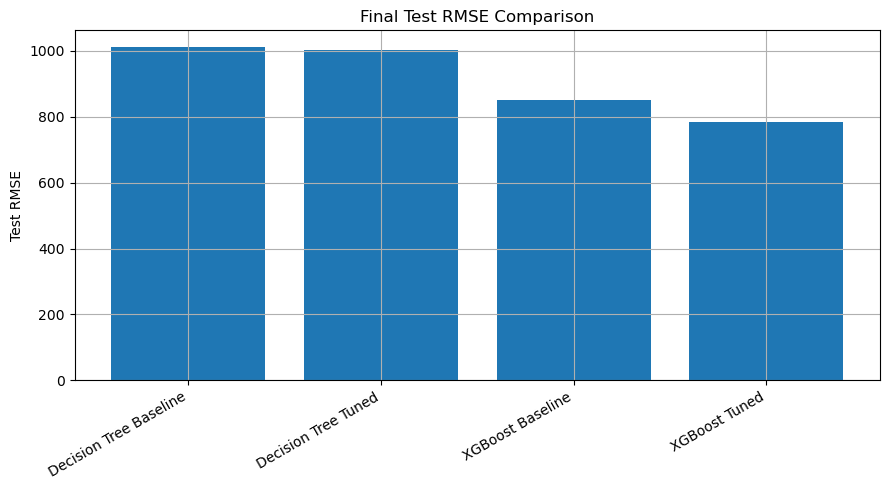

In [40]:
# Bar chart of final test RMSE values
plt.figure(figsize=(9, 5))
plt.bar(model_results_df.index, model_results_df["RMSE"])
plt.ylabel("Test RMSE")
plt.title("Final Test RMSE Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_model_rmse_comparison.png", dpi=300)
plt.show()

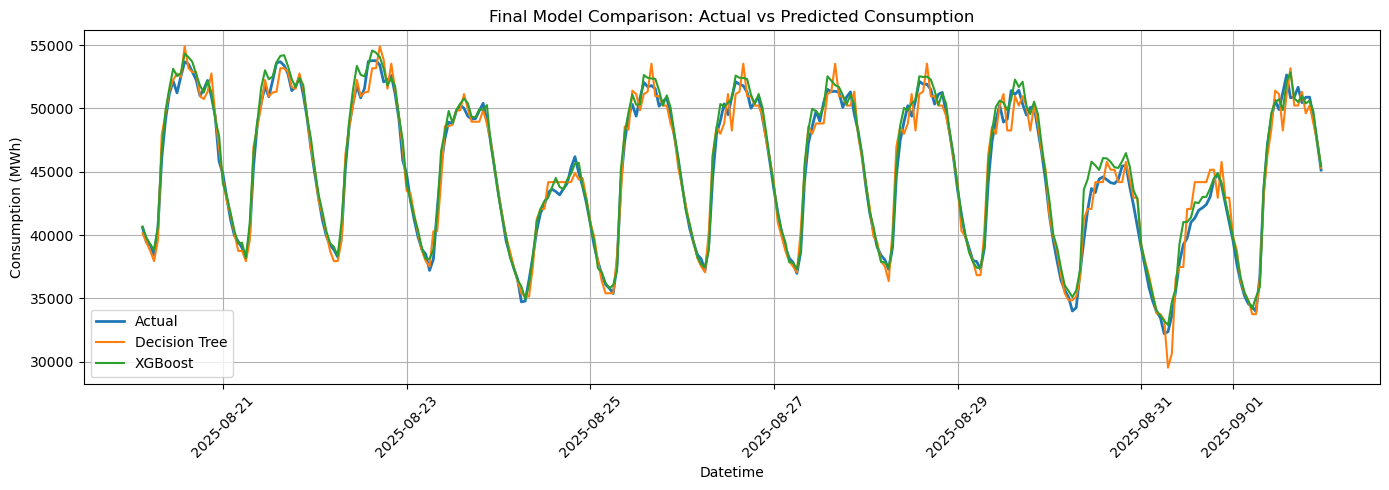

In [41]:
# Actual vs predicted comparison for tuned models
plt.figure(figsize=(14, 5))
plt.plot(test_datetimes, y_test.values, label="Actual", linewidth=2)
plt.plot(test_datetimes, tree_test_pred, label="Decision Tree")
plt.plot(test_datetimes, xgb_test_pred, label="XGBoost")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MWh)")
plt.title("Final Model Comparison: Actual vs Predicted Consumption")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_actual_vs_predicted_comparison.png", dpi=300)
plt.show()

In [42]:
# Save final results table for slides/report
model_results_df.to_csv(FIGURES_DIR / "final_model_results.csv")
print("Saved figures and result table to:", FIGURES_DIR)

Saved figures and result table to: C:\Users\casua\Desktop\machine-learning-term-project\figures\results


# 8. Interpretation, Limitations, and Future Work

## Interpretation

The models use time-based and historical system-state features to predict hourly electricity consumption. If lagged consumption features such as `Tuketim_lag_1`, `Tuketim_lag_24`, or rolling consumption means appear among the most important features, this supports the assumption that electricity consumption has strong short-term and daily temporal dependence.

## Limitations

- The dataset covers only June to early September, so full annual seasonality is not represented.
- Weather variables such as temperature, humidity, wind speed, and solar irradiance are not included.
- Holiday and calendar-event information is not included.
- Same-hour production values are excluded to avoid feature availability leakage in the forecasting setup.